En este archivo se evalúan los supuestos para los modelos SARIMA correspondientes.

In [4]:
#LIBRERIAS IMPORTADAS
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import statsmodels.api as sm
from scipy.stats import jarque_bera
from pathlib import Path
import joblib

Se procede a descargar todos los modelos SARIMA a evaluar

In [5]:
CARPETA_MODELOS = Path("modelos")

rutas_sarima = sorted(
    CARPETA_MODELOS.glob(
        "SARIMA_US_Stock_*_adj_close.joblib"
    )
)

print(f"Modelos SARIMA encontrados: {len(rutas_sarima)}")

for ruta in rutas_sarima:
    print(ruta.name)

Modelos SARIMA encontrados: 25
SARIMA_US_Stock_ACWI_adj_close.joblib
SARIMA_US_Stock_BNDX_adj_close.joblib
SARIMA_US_Stock_CVE_adj_close.joblib
SARIMA_US_Stock_CVX_adj_close.joblib
SARIMA_US_Stock_DVN_adj_close.joblib
SARIMA_US_Stock_EWT_adj_close.joblib
SARIMA_US_Stock_HAL_adj_close.joblib
SARIMA_US_Stock_HES_adj_close.joblib
SARIMA_US_Stock_IEF_adj_close.joblib
SARIMA_US_Stock_IEMG_adj_close.joblib
SARIMA_US_Stock_JNK_adj_close.joblib
SARIMA_US_Stock_MPC_adj_close.joblib
SARIMA_US_Stock_OIH_adj_close.joblib
SARIMA_US_Stock_OKE_adj_close.joblib
SARIMA_US_Stock_OXY_adj_close.joblib
SARIMA_US_Stock_RSP_adj_close.joblib
SARIMA_US_Stock_RY_adj_close.joblib
SARIMA_US_Stock_SLV_adj_close.joblib
SARIMA_US_Stock_TRGP_adj_close.joblib
SARIMA_US_Stock_VALE_adj_close.joblib
SARIMA_US_Stock_VT_adj_close.joblib
SARIMA_US_Stock_VYM_adj_close.joblib
SARIMA_US_Stock_WMB_adj_close.joblib
SARIMA_US_Stock_X_adj_close.joblib
SARIMA_US_Stock_XOM_adj_close.joblib


In [23]:
def evaluar_supuestos_sarima(modelo, nombre, lags=(12, 24)):

    residuos = (pd.Series(modelo.resid()).dropna() )

    # Ljung-Box

    lb = acorr_ljungbox(residuos,lags=list(lags),return_df=True)

    # Jarque-Bera

    jb = jarque_bera(residuos) #Para normalidad

    # ARCH

    arch = het_arch(residuos)

    resultado = {
        "modelo": nombre,

        "n_residuos":
            len(residuos),

        "media_residuos":
            residuos.mean(),

        "std_residuos":
            residuos.std(),

        "JB_p":
            jb.pvalue,

        "ARCH_p":
            arch[1]
    }

    # Un p-value por lag
    for lag in lags:

        resultado[f"LjungBox_{lag}_p"] = lb.loc[lag,"lb_pvalue"]

    return resultado

In [30]:
def diagnosticos_graficos(modelo,nombre,lags=36):

    residuos = (pd.Series(modelo.resid()).dropna())

    # Residuos vs tiempo

    plt.figure(figsize=(12, 4))

    plt.plot(residuos)

    plt.axhline(0,linestyle="--")

    plt.title(f"Residuos - {nombre}")

    plt.show()


    # ACF

    plot_acf(residuos,lags=lags)

    plt.title(f"ACF residuos - {nombre}")

    plt.show()


    # Histograma

    plt.figure(figsize=(8, 5))

    plt.hist(residuos,bins=30)

    plt.title(f"Histograma residuos - {nombre}")

    plt.show()

    # Q-Q Plot

    sm.qqplot(residuos,line="45")

    plt.title(f"Q-Q residuos - {nombre}")

    plt.show()

In [8]:
#Se procede a cargar los modelos antes implementados en un diccionario
PREFIJO = "SARIMA_US_Stock_"
SUFIJO = "_adj_close"
modelos_sarima = {}

for ruta in rutas_sarima:

    nombre = ruta.stem

    variable = nombre[
        len(PREFIJO):
        -len(SUFIJO)
    ]

    modelos_sarima[variable] = joblib.load(ruta)

In [11]:
print(modelos_sarima.keys())

dict_keys(['ACWI', 'BNDX', 'CVE', 'CVX', 'DVN', 'EWT', 'HAL', 'HES', 'IEF', 'IEMG', 'JNK', 'MPC', 'OIH', 'OKE', 'OXY', 'RSP', 'RY', 'SLV', 'TRGP', 'VALE', 'VT', 'VYM', 'WMB', 'X', 'XOM'])


## Evaluación de supuestos

### Análisis numérico

In [24]:
resultados = []

for variable, modelo in modelos_sarima.items():

    resultado = evaluar_supuestos_sarima(modelo,nombre=variable,lags=(12, 24, 36)) #lags con estacionalidad mensual

    resultados.append(resultado)

In [25]:
tabla_supuestos = pd.DataFrame(resultados)
display(tabla_supuestos.round(4))

,modelo,n_residuos,media_residuos,std_residuos,JB_p,ARCH_p,LjungBox_12_p,LjungBox_24_p,LjungBox_36_p
0,ACWI,1764,0.0027,0.0995,0.0,0.0000,1.0000,1.0000,1.0000
1,BNDX,1764,0.0022,0.0898,0.0,0.0000,1.0000,1.0000,1.0000
2,CVE,1764,0.0015,0.0621,0.0,0.0003,0.9954,0.9988,0.9999
3,CVX,1764,0.0028,0.1095,0.0,0.0000,1.0000,1.0000,1.0000
4,DVN,1764,0.0021,0.0881,0.0,0.0000,1.0000,1.0000,1.0000
5,EWT,1764,0.0022,0.0772,0.0,0.0000,1.0000,1.0000,1.0000
6,HAL,1764,0.0020,0.0951,0.0,0.0000,1.0000,1.0000,1.0000
7,HES,1764,0.0027,0.0939,0.0,0.0000,1.0000,1.0000,1.0000
8,IEF,1764,0.0026,0.1072,0.0,0.0000,1.0000,1.0000,1.0000
9,IEMG,1764,0.0023,0.0929,0.0,0.0000,1.0000,1.0000,1.0000


### Análisis gráfico


SARIMA - ACWI


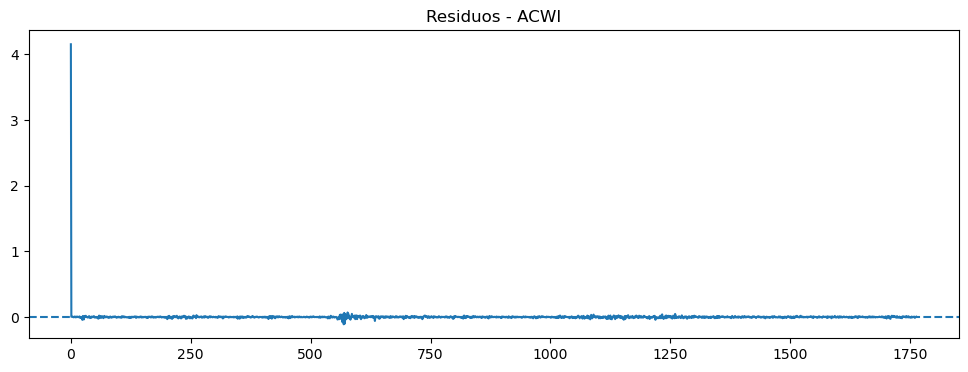

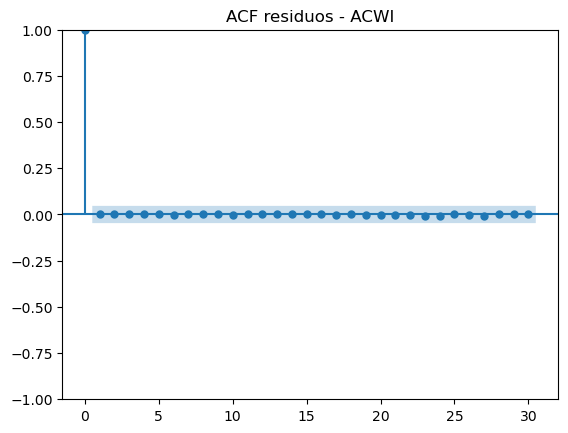

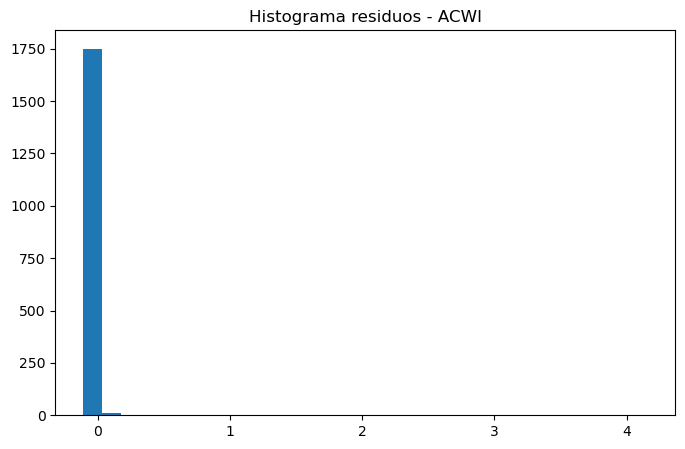

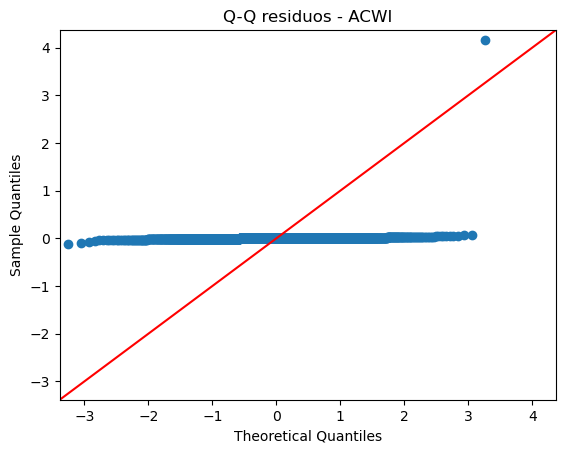


SARIMA - BNDX


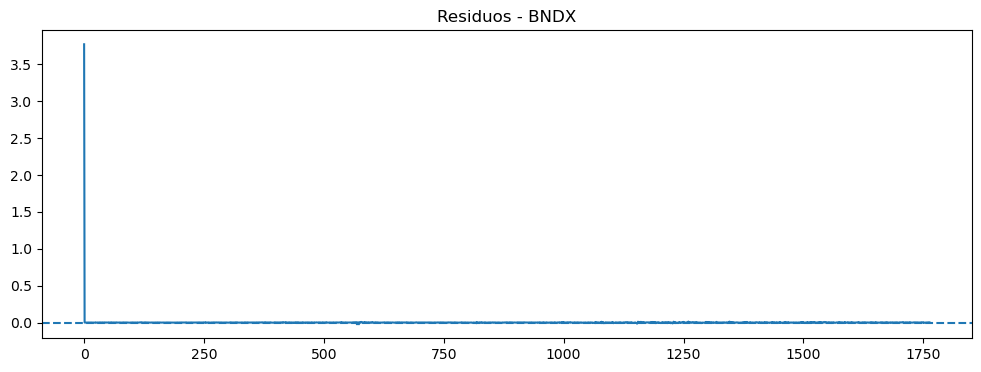

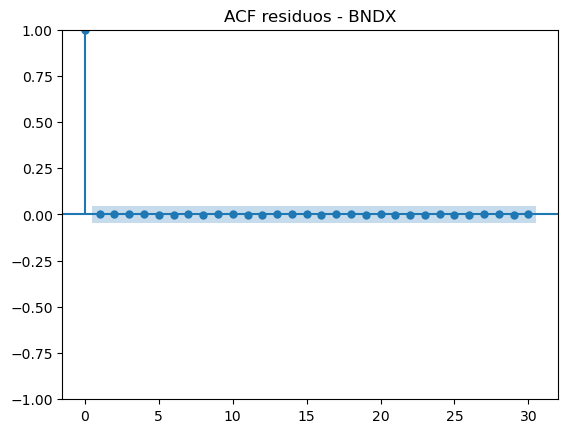

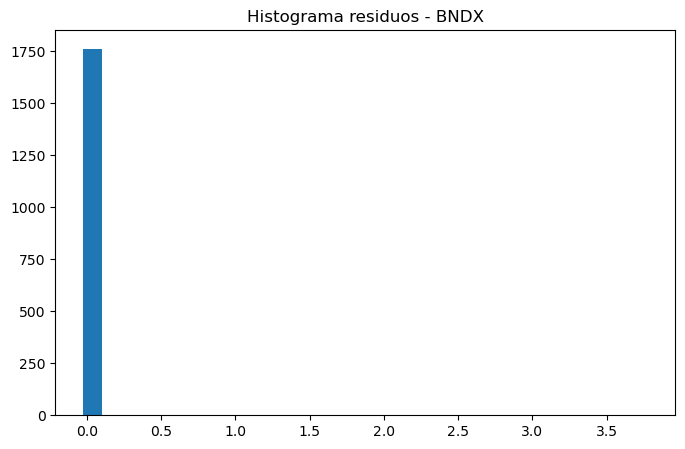

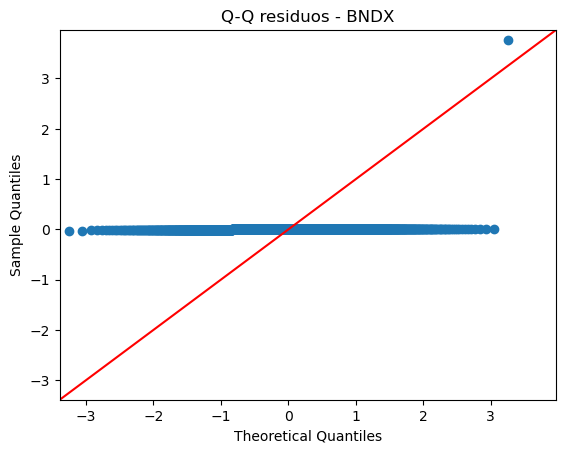


SARIMA - CVE


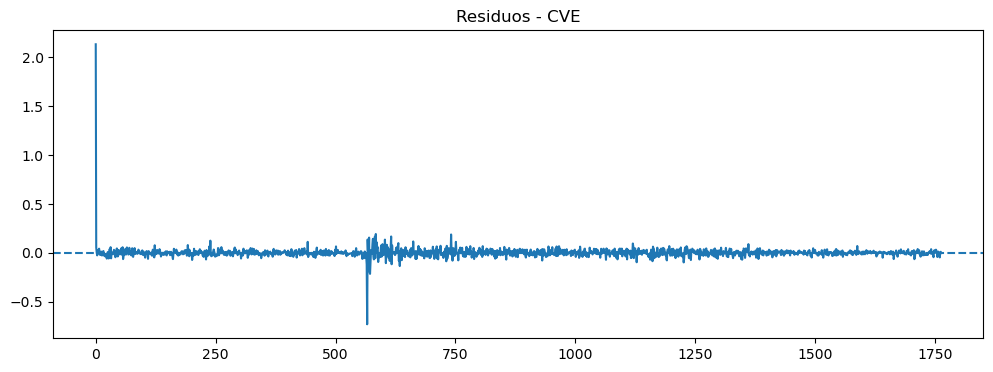

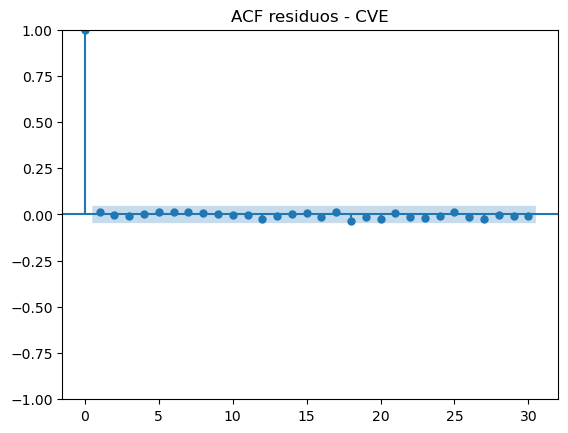

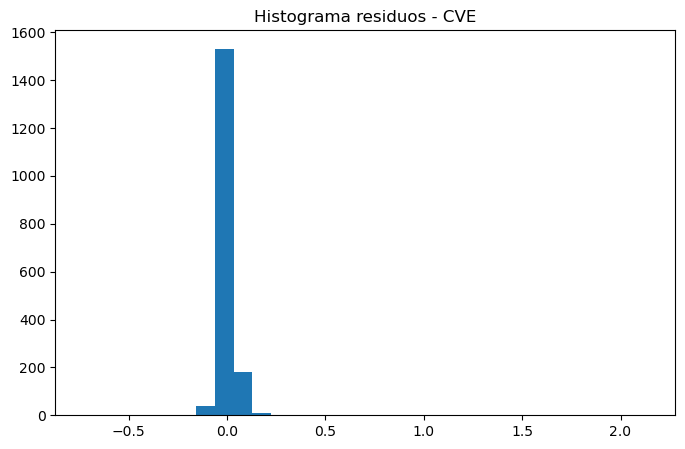

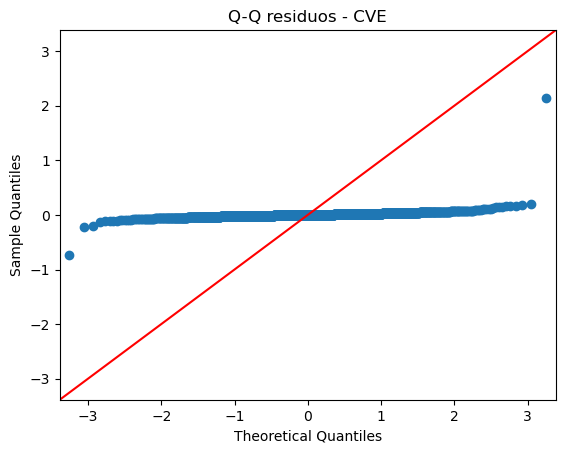


SARIMA - CVX


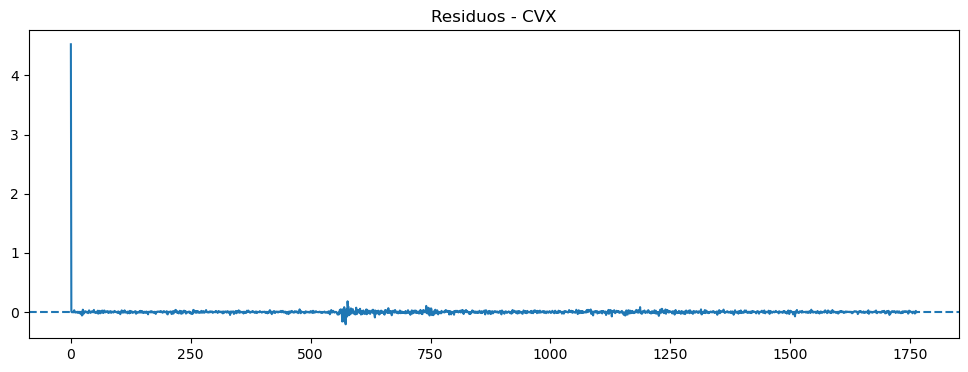

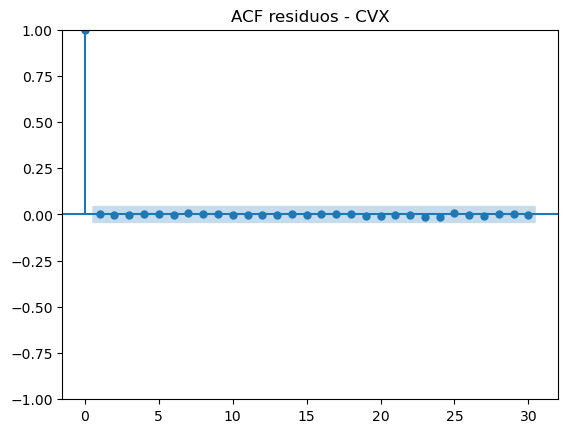

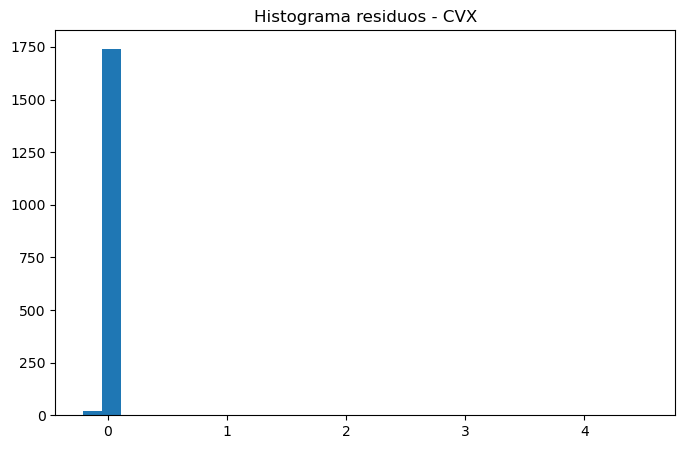

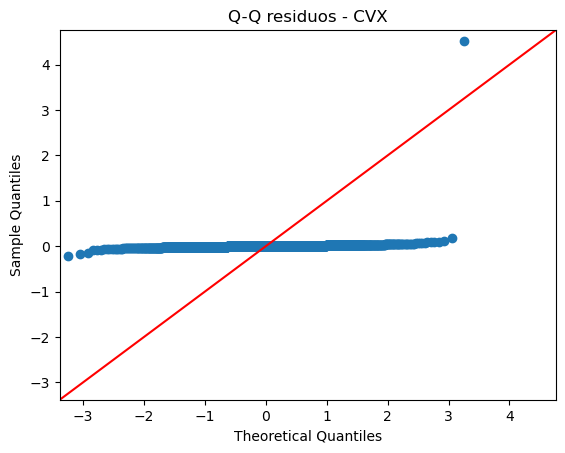


SARIMA - DVN


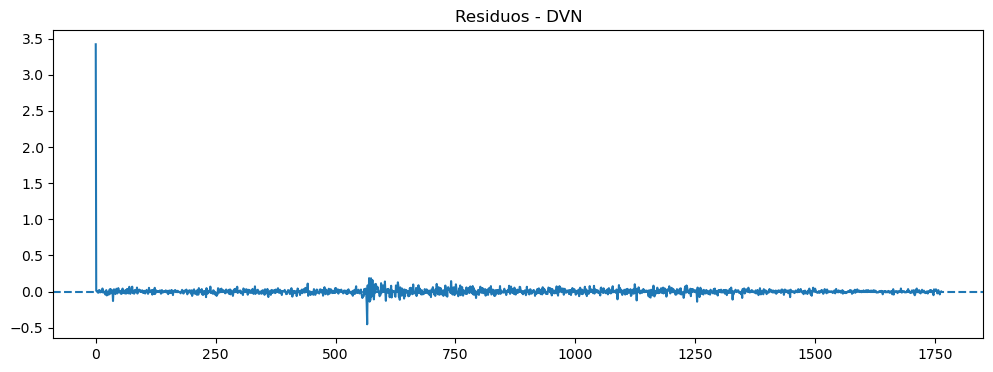

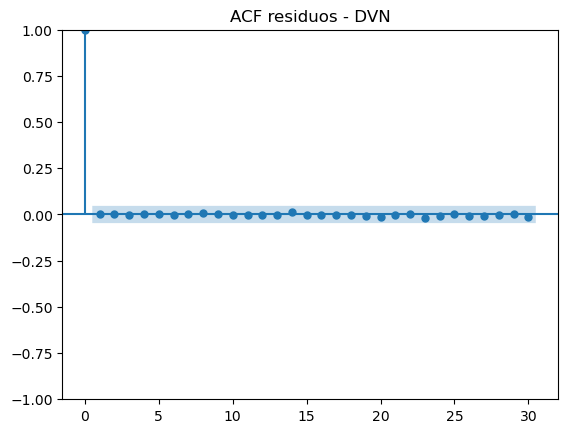

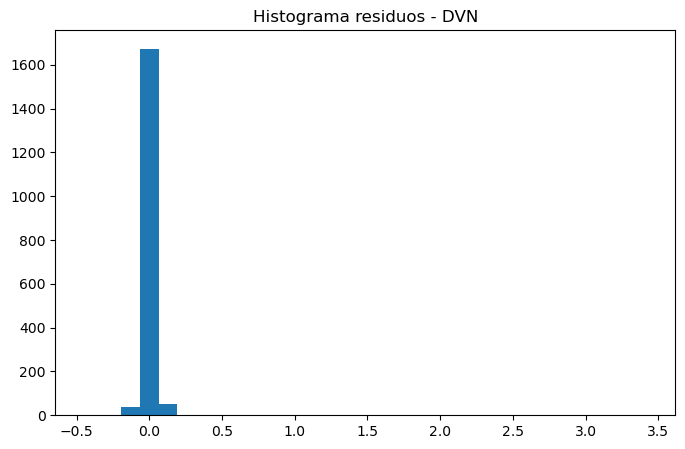

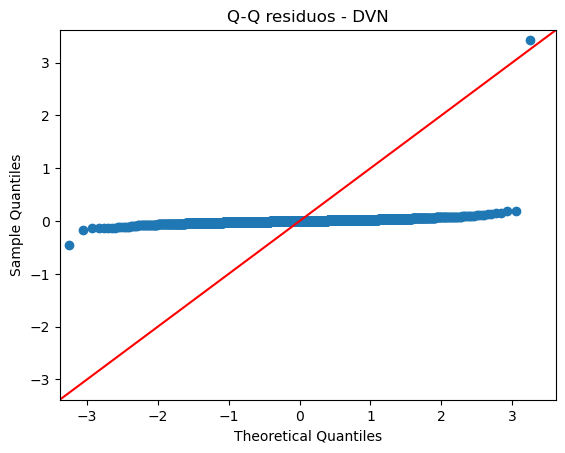


SARIMA - EWT


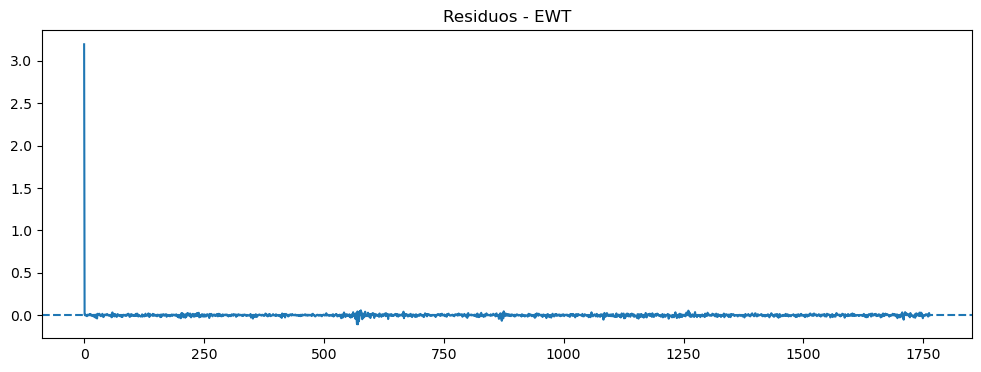

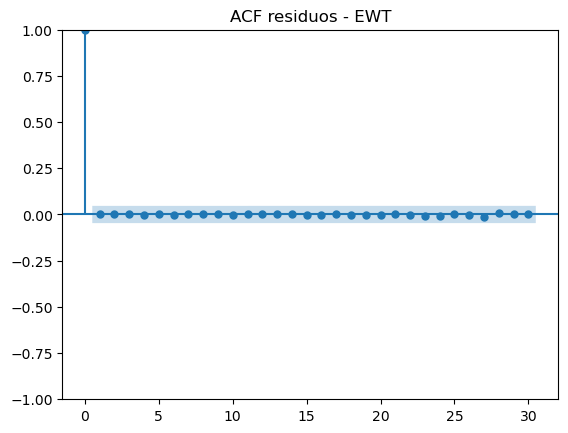

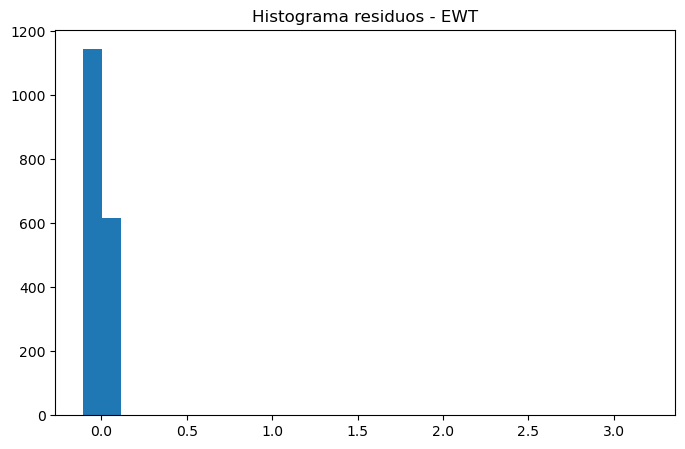

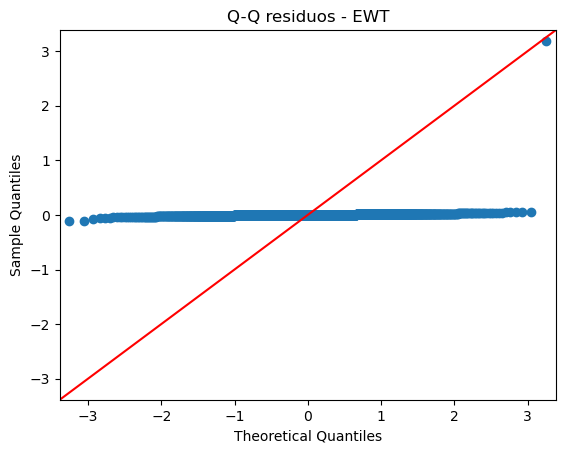


SARIMA - HAL


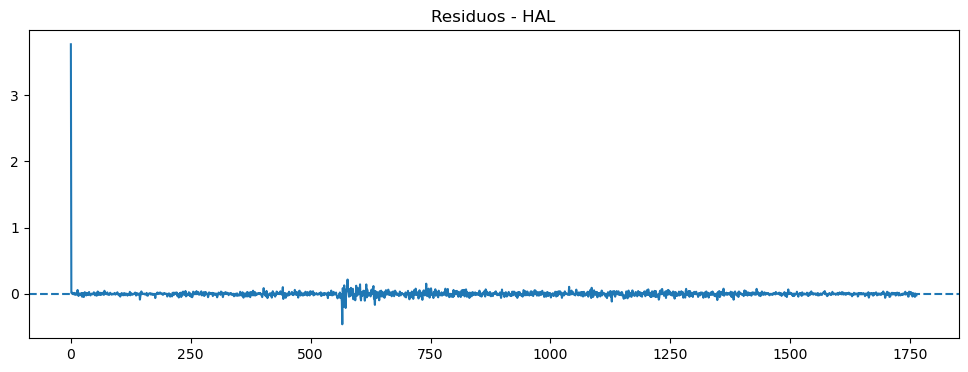

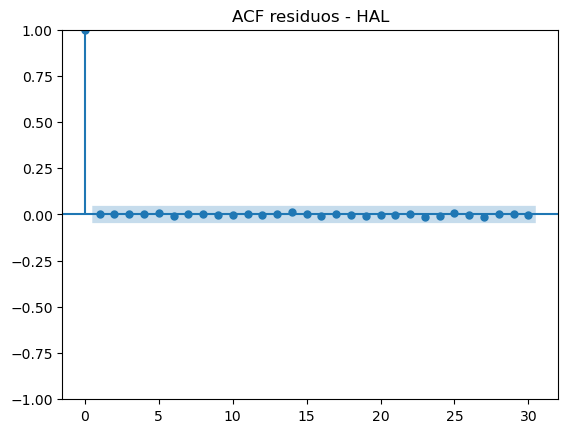

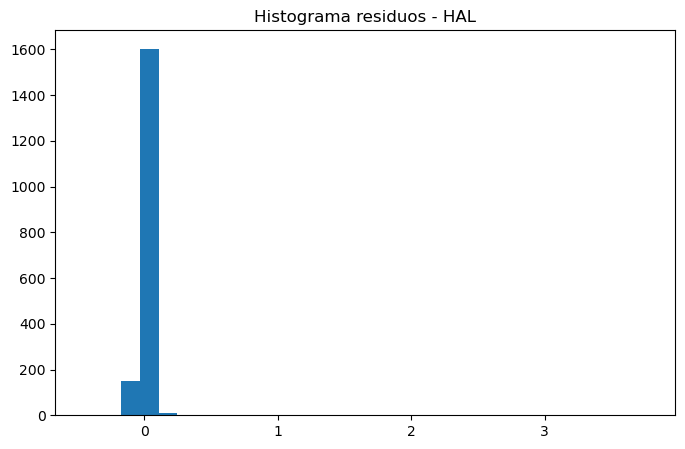

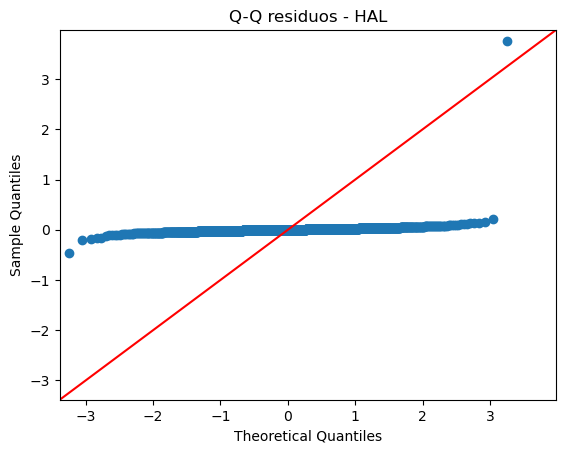


SARIMA - HES


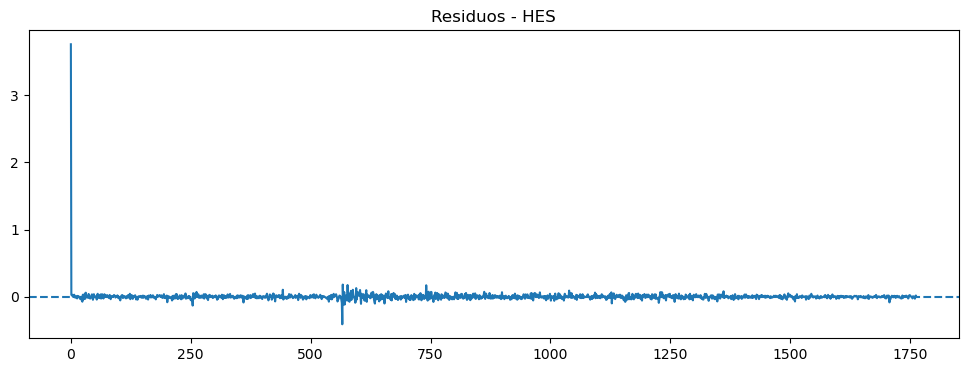

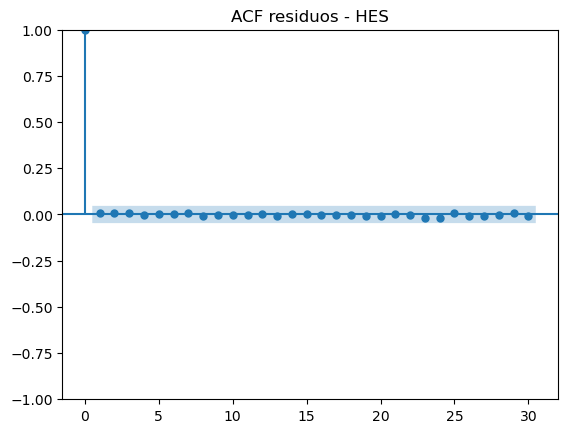

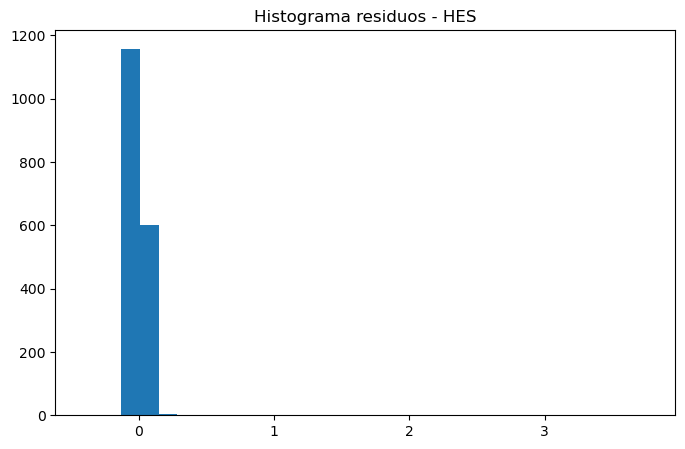

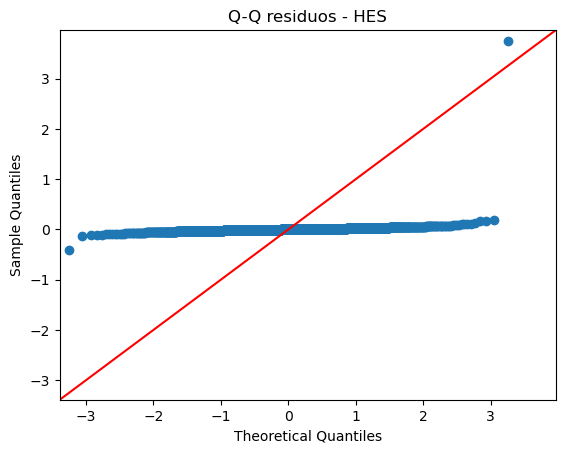


SARIMA - IEF


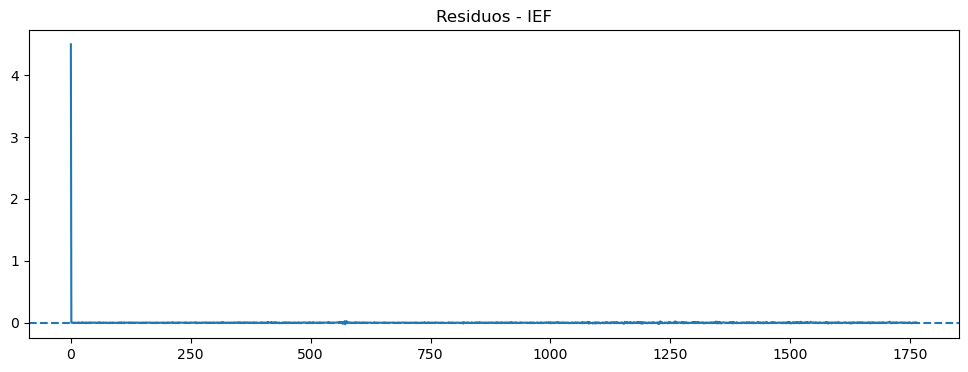

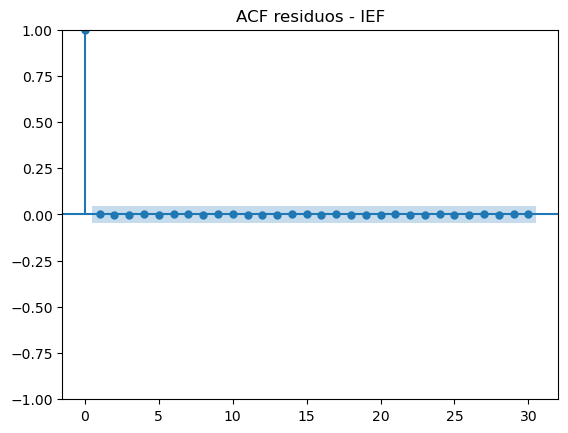

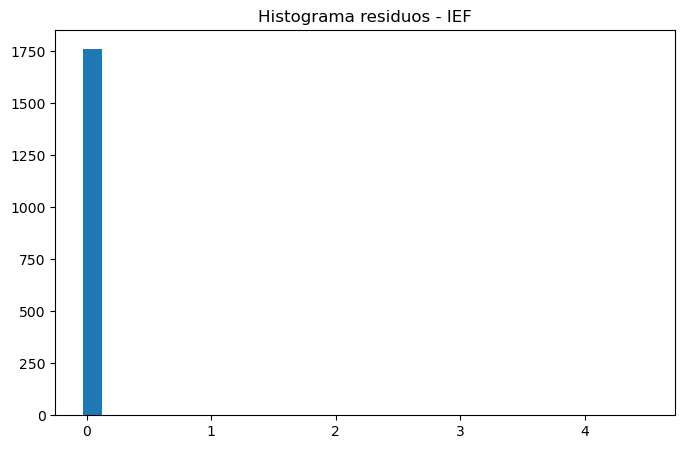

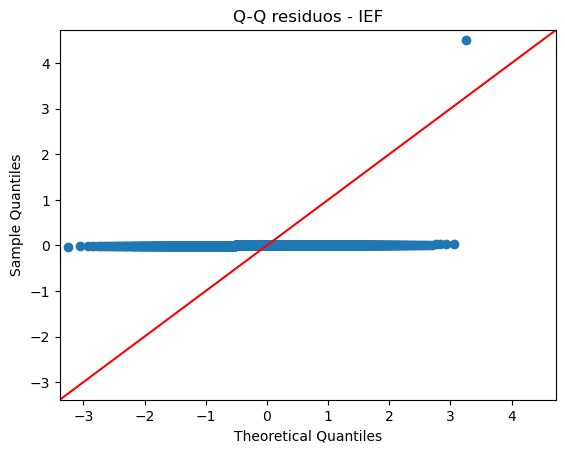


SARIMA - IEMG


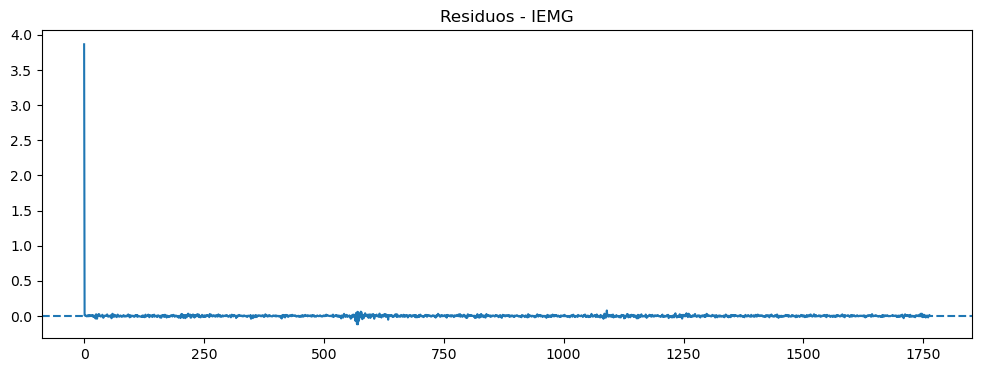

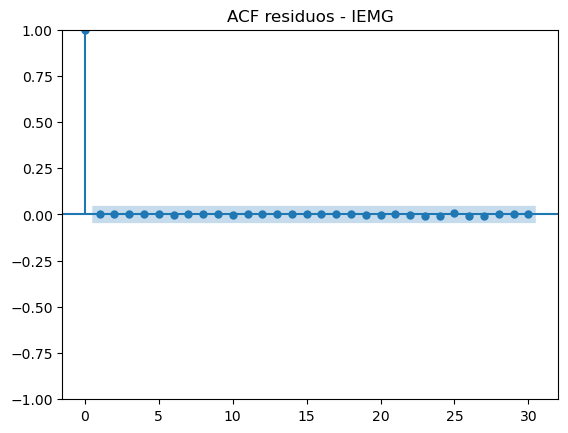

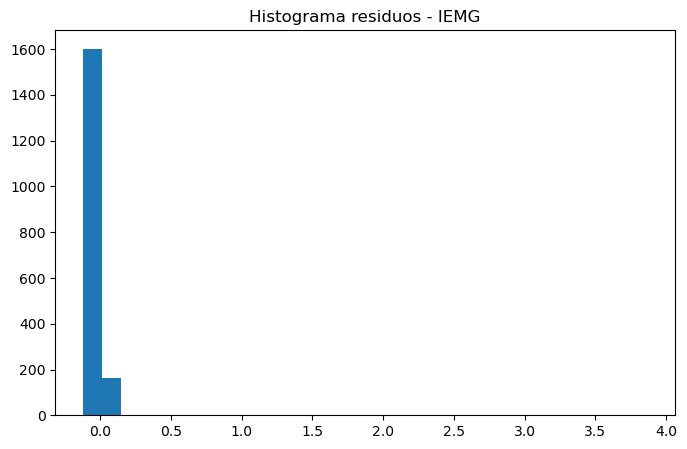

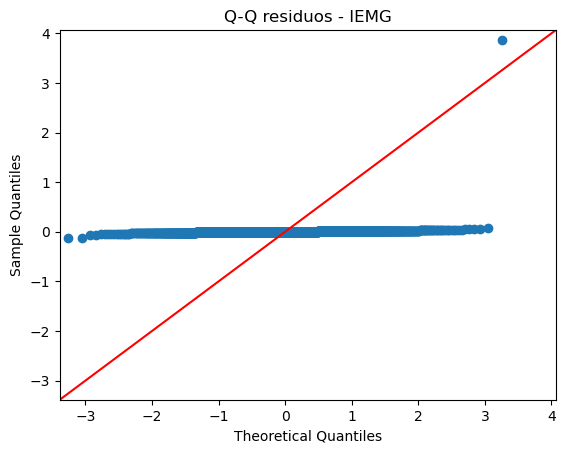


SARIMA - JNK


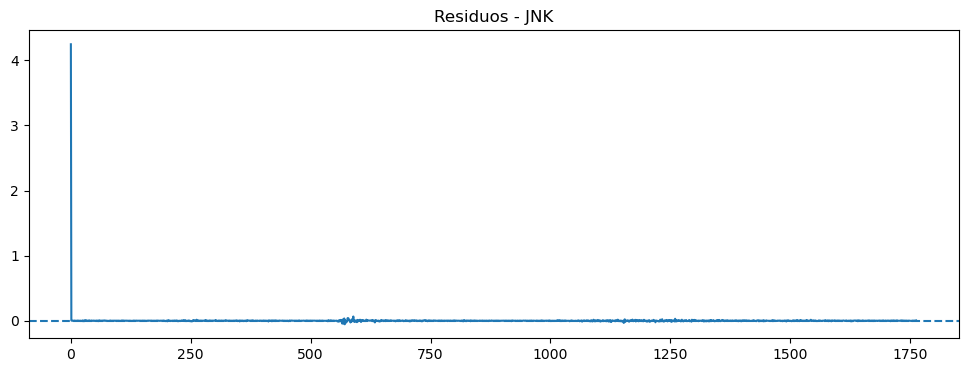

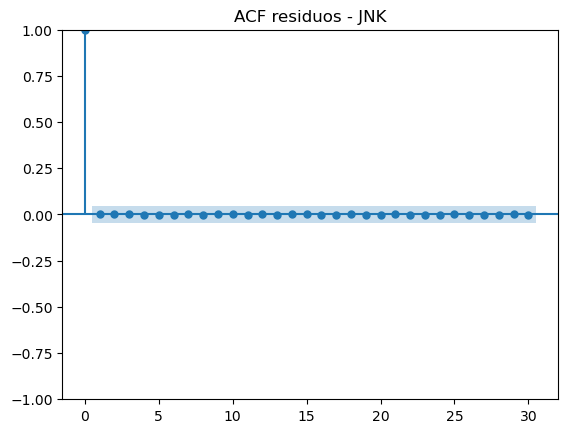

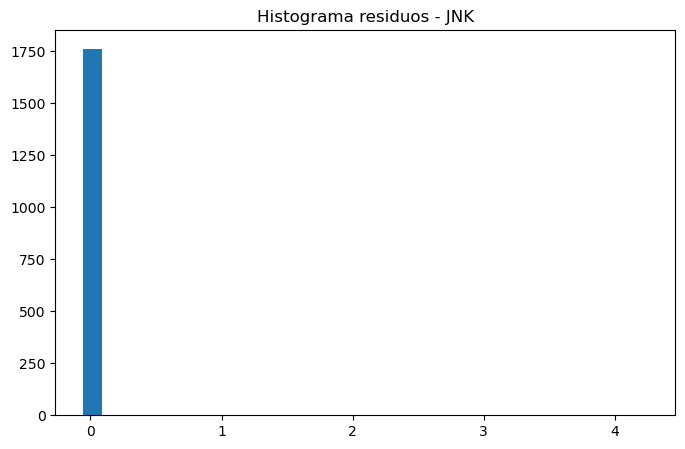

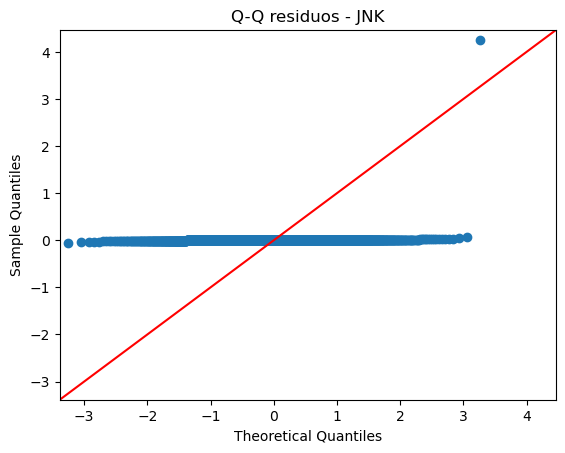


SARIMA - MPC


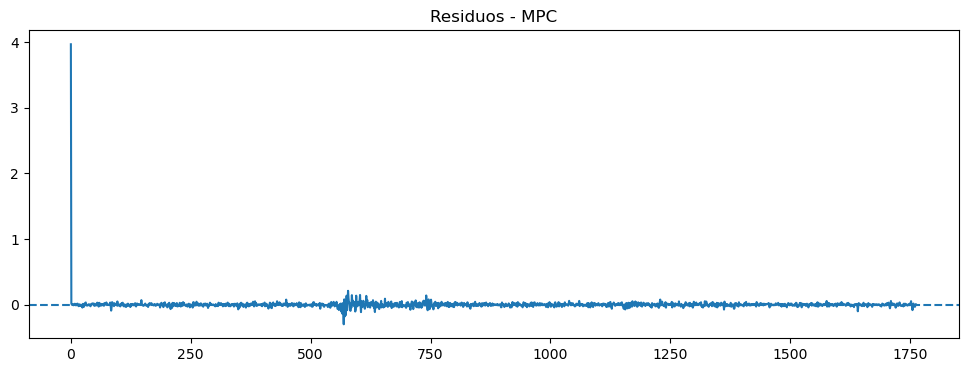

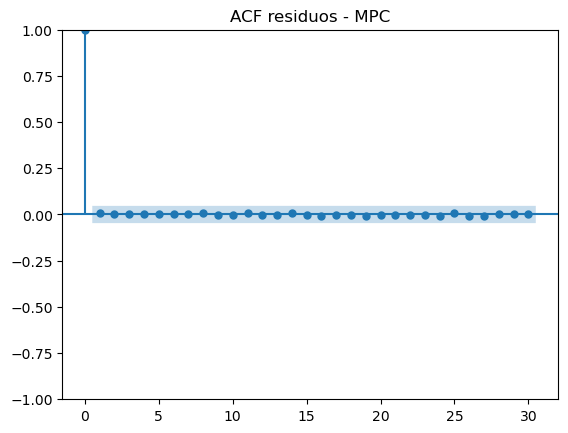

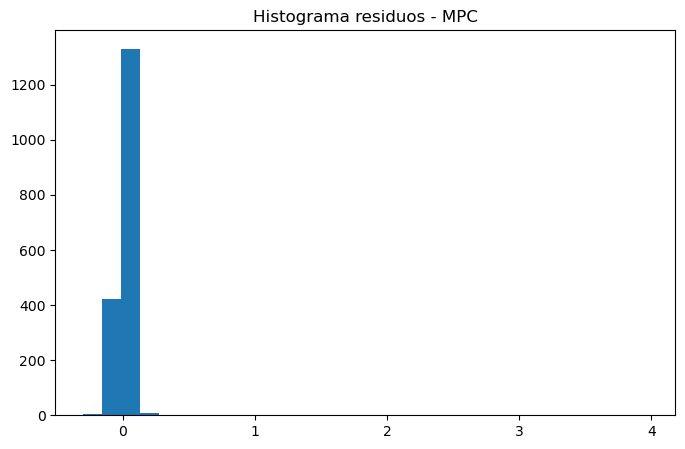

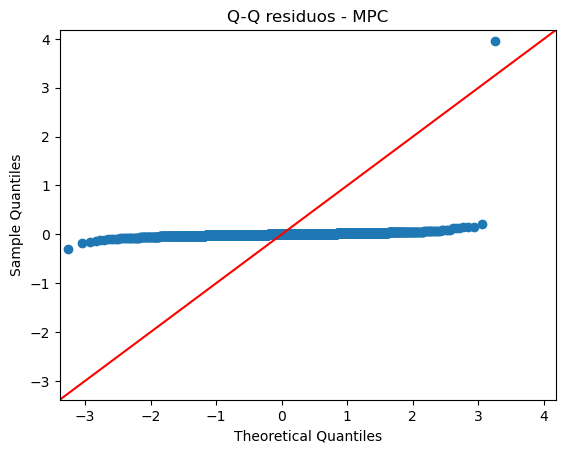


SARIMA - OIH


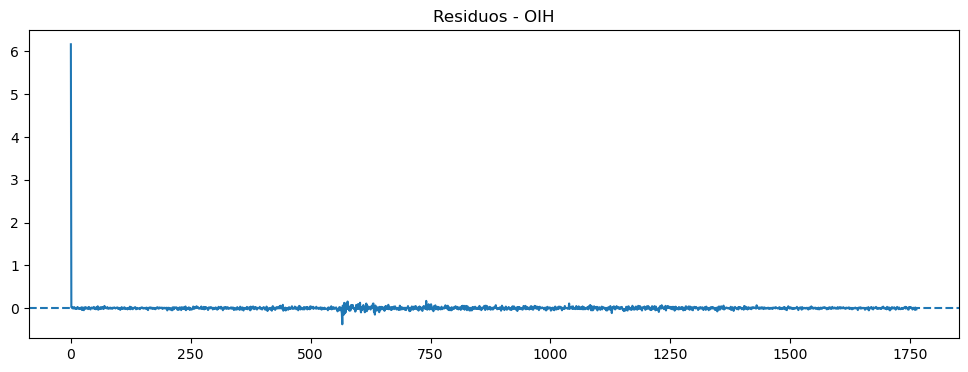

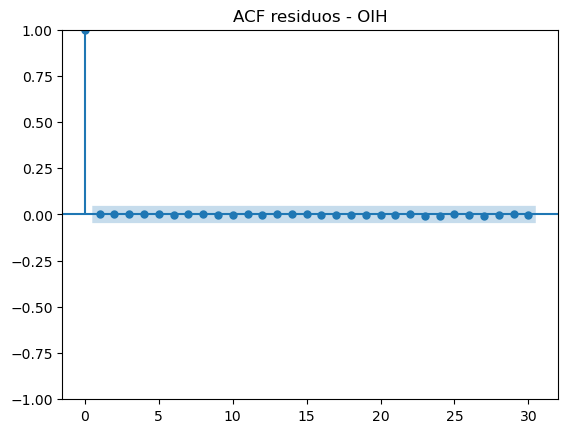

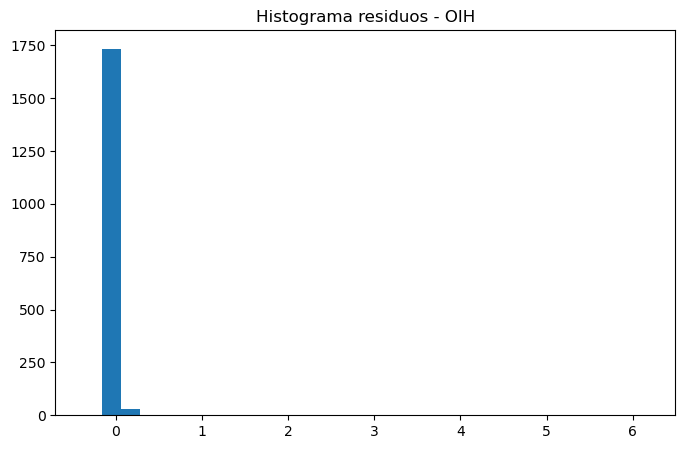

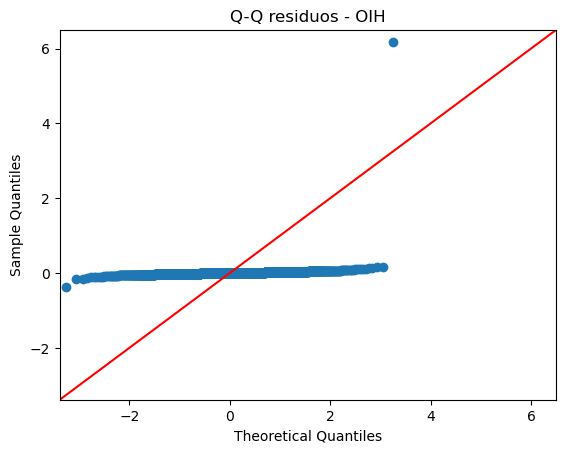


SARIMA - OKE


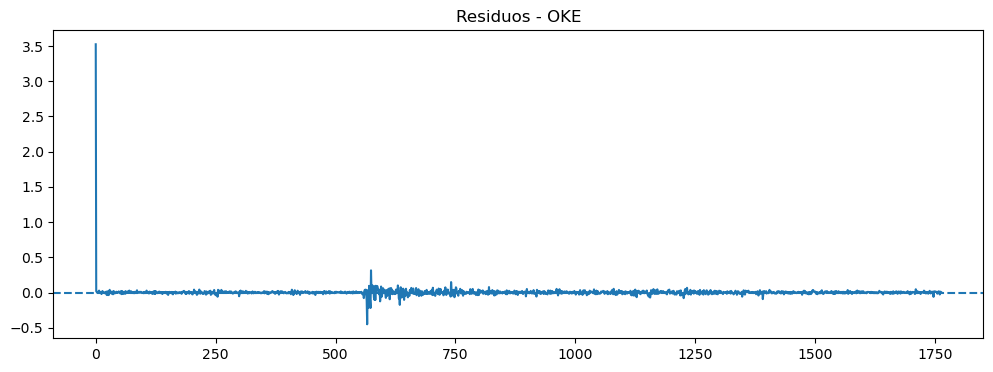

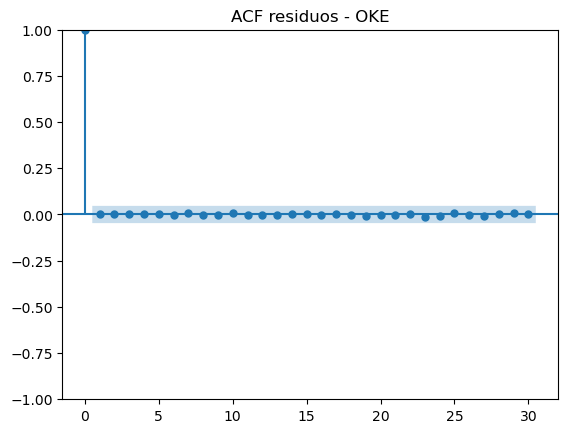

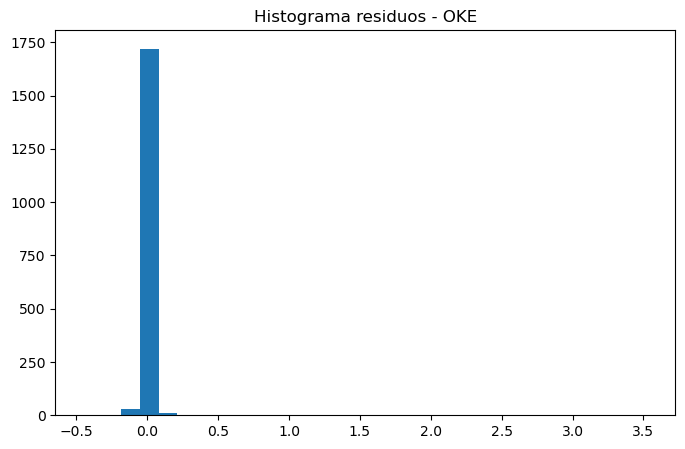

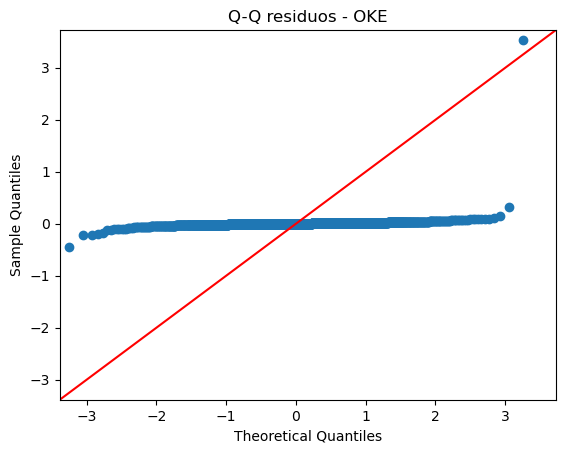


SARIMA - OXY


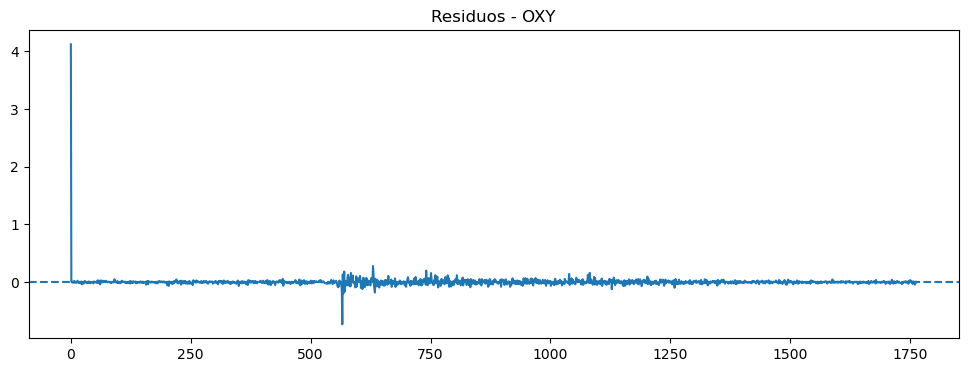

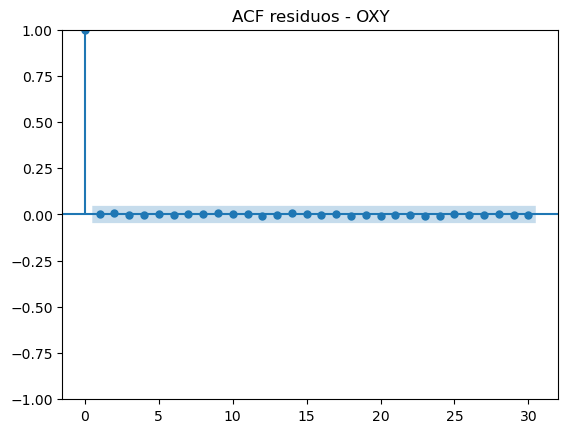

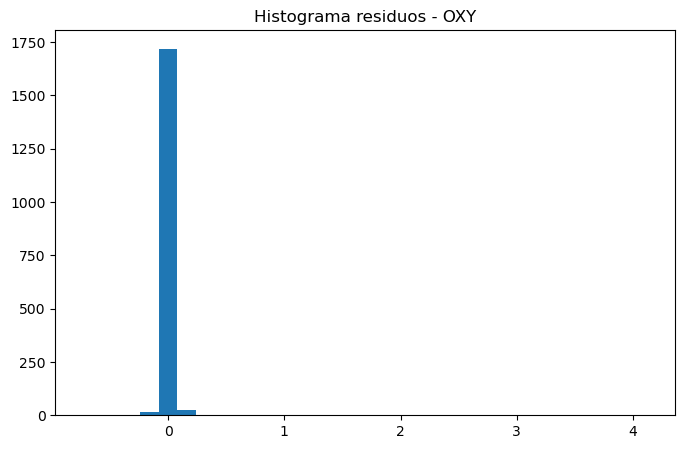

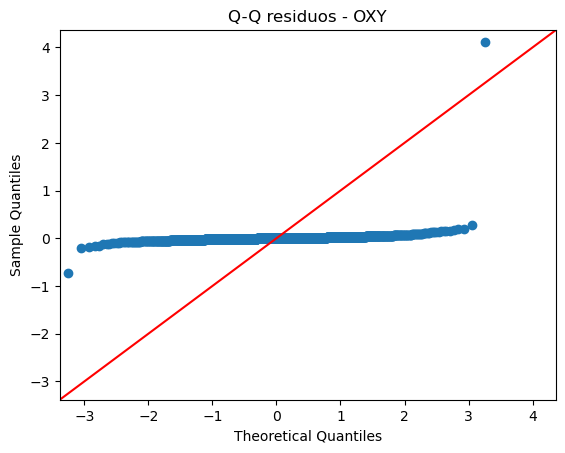


SARIMA - RSP


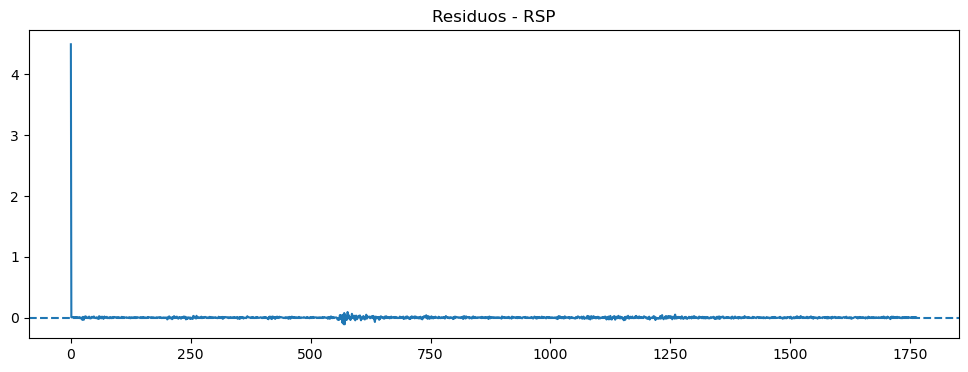

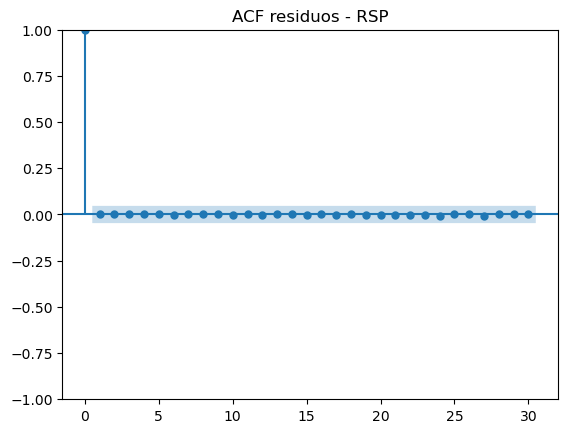

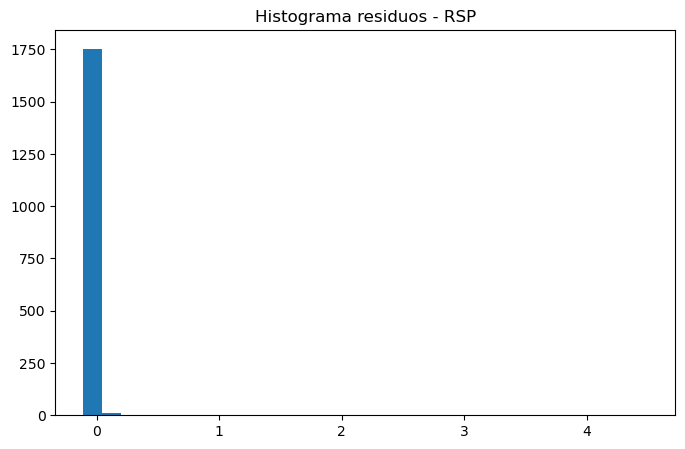

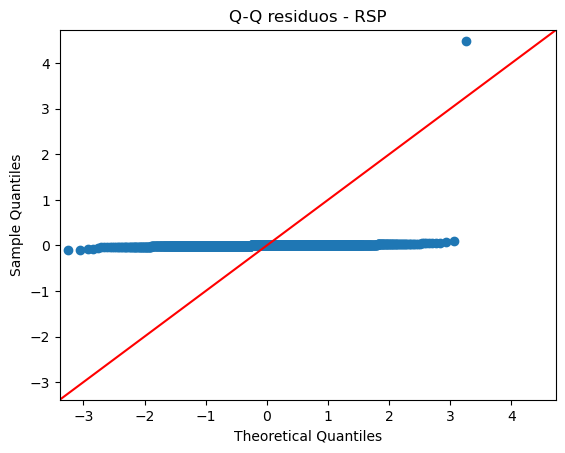


SARIMA - RY


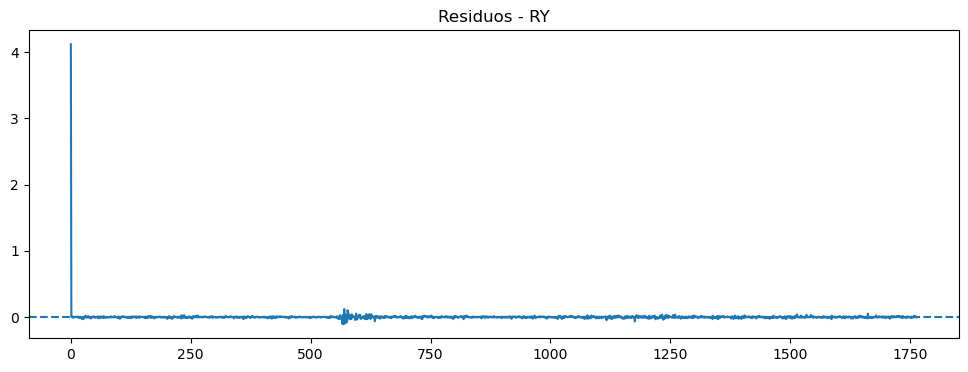

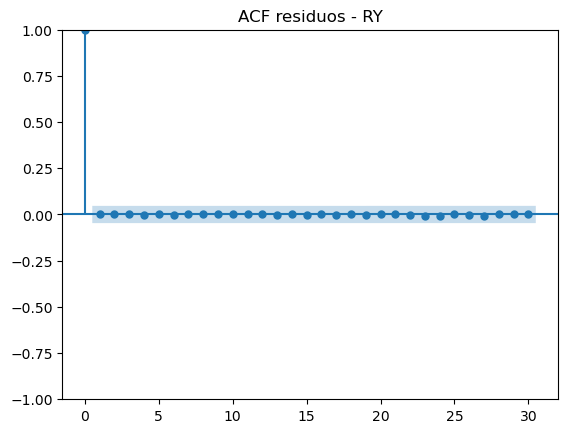

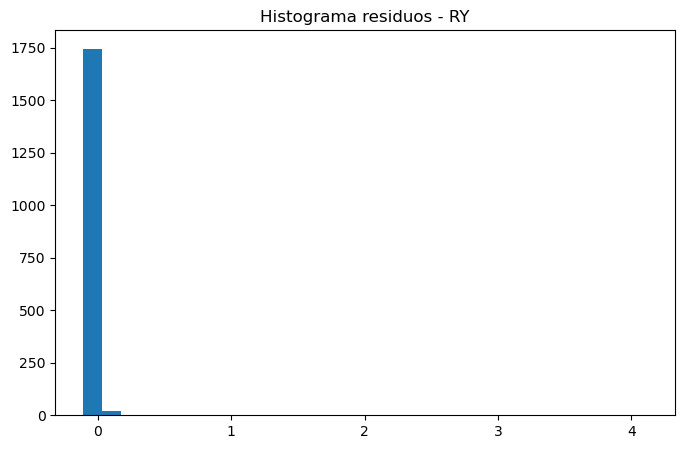

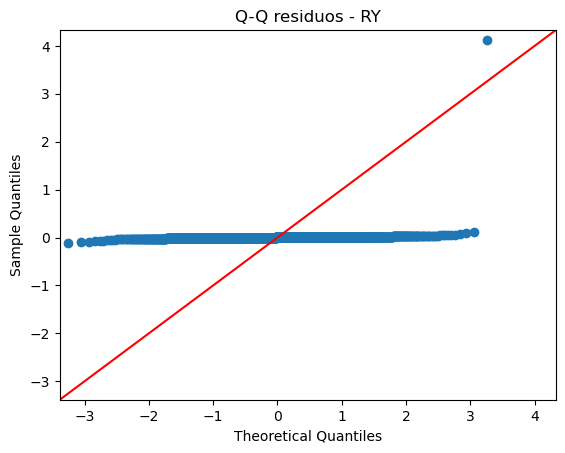


SARIMA - SLV


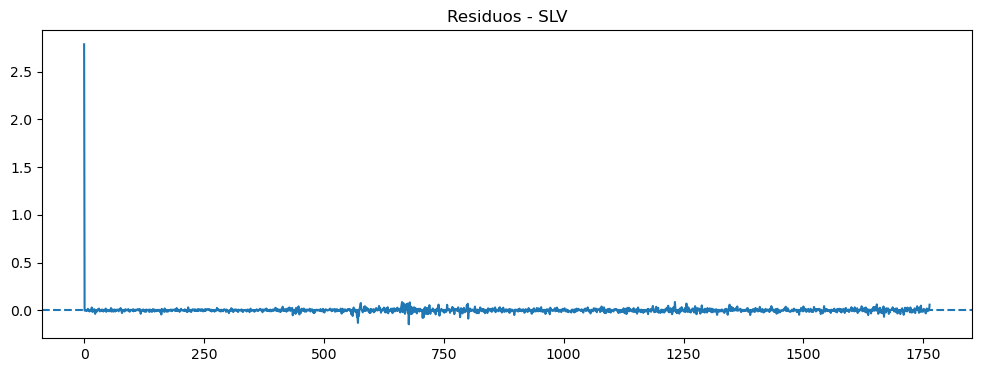

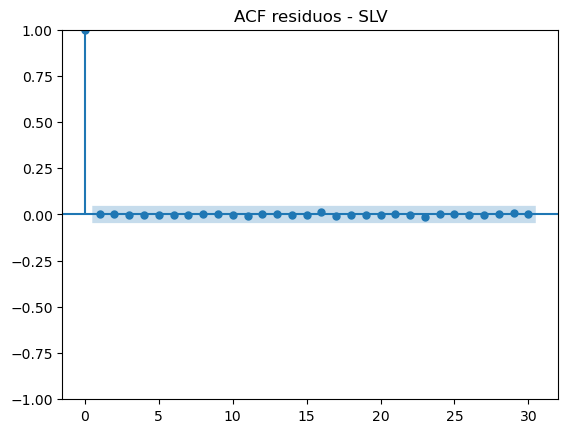

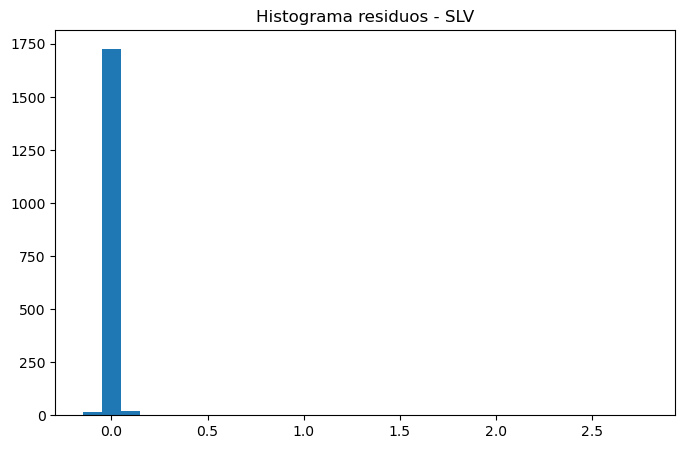

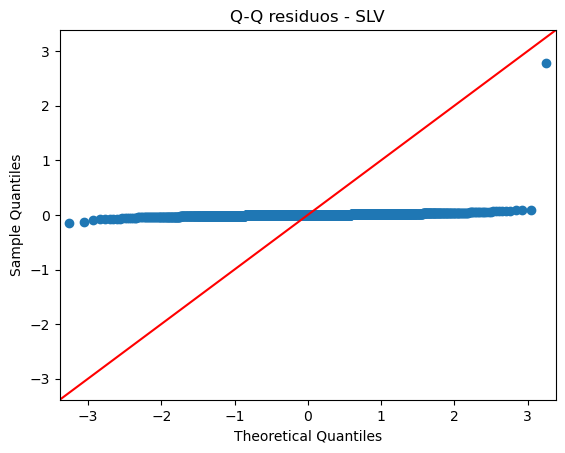


SARIMA - TRGP


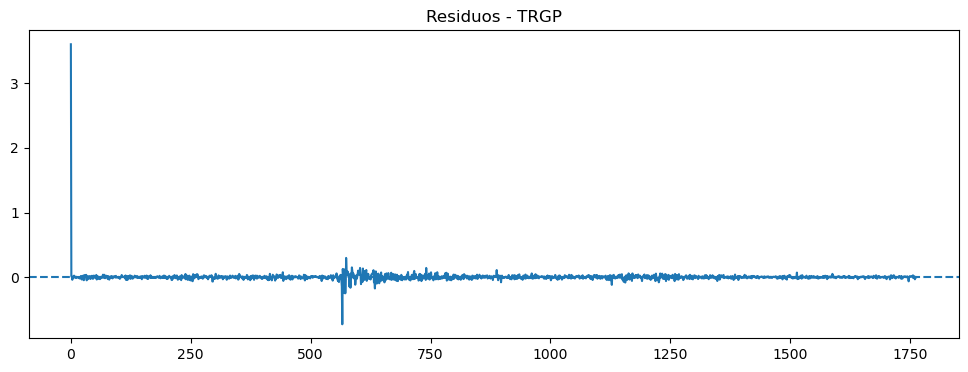

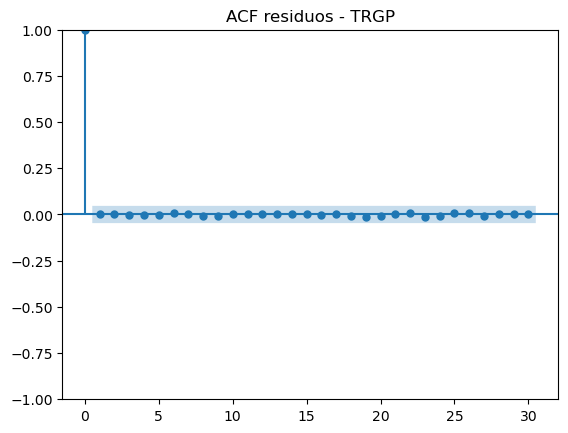

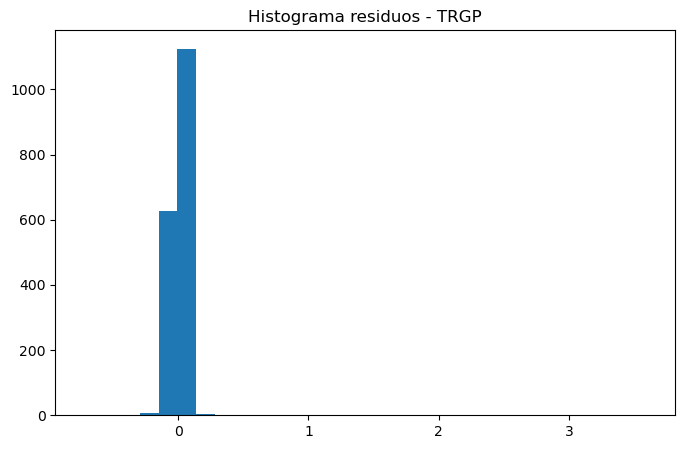

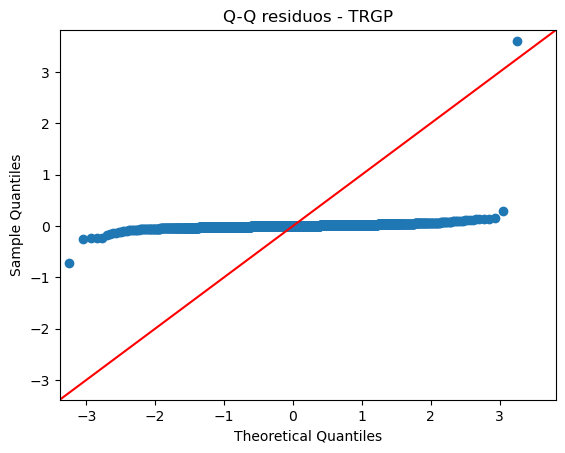


SARIMA - VALE


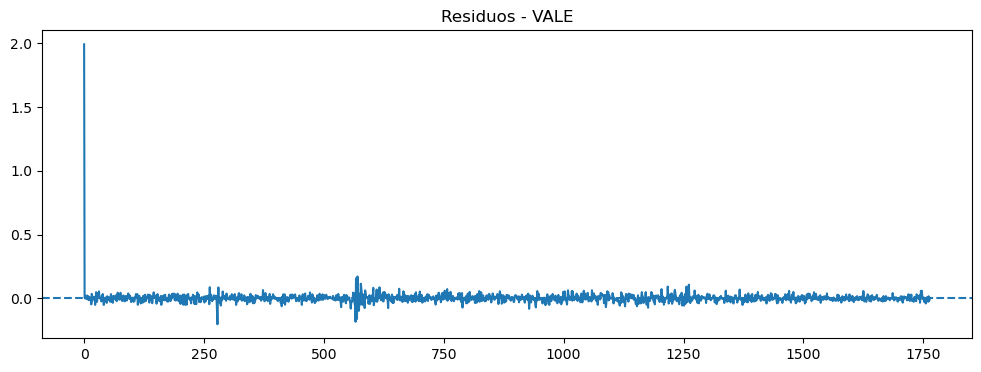

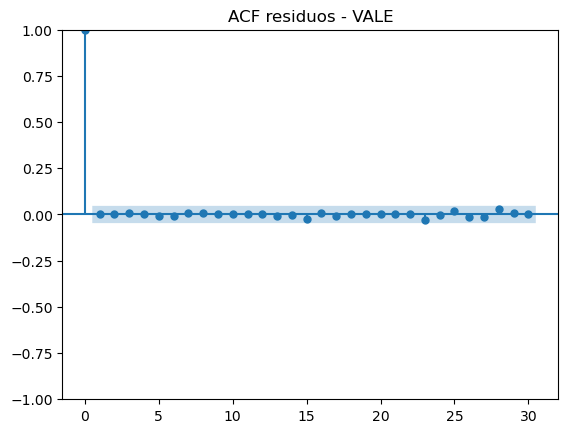

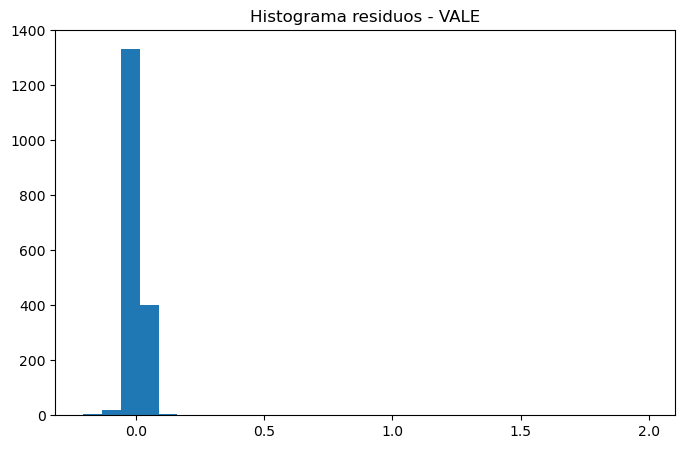

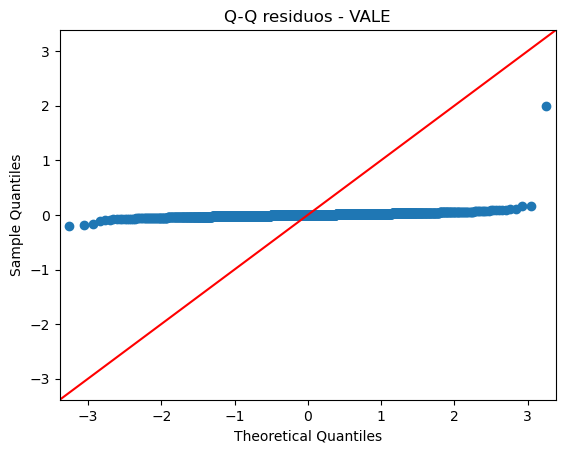


SARIMA - VT


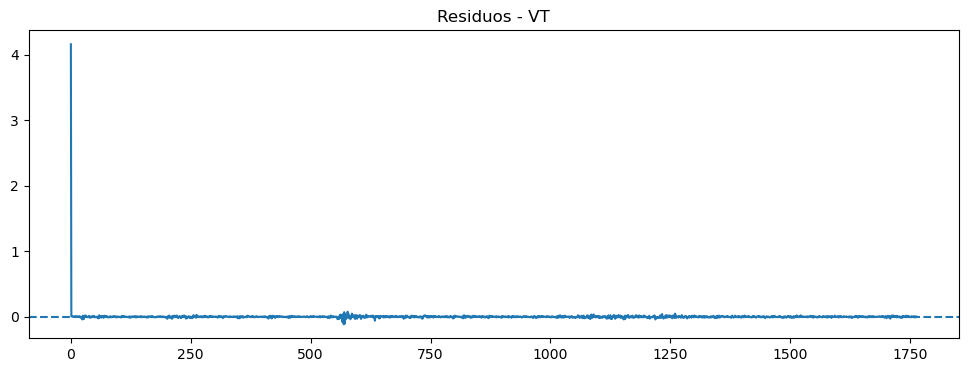

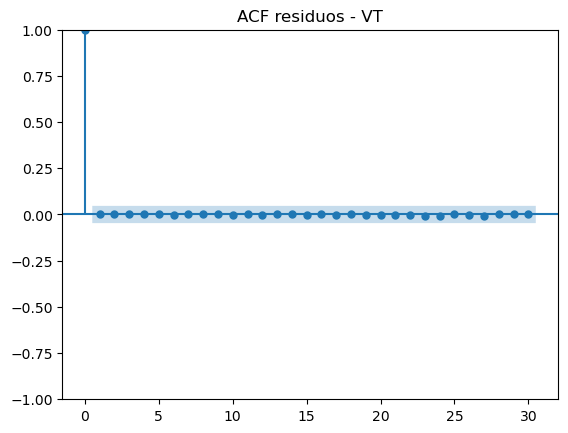

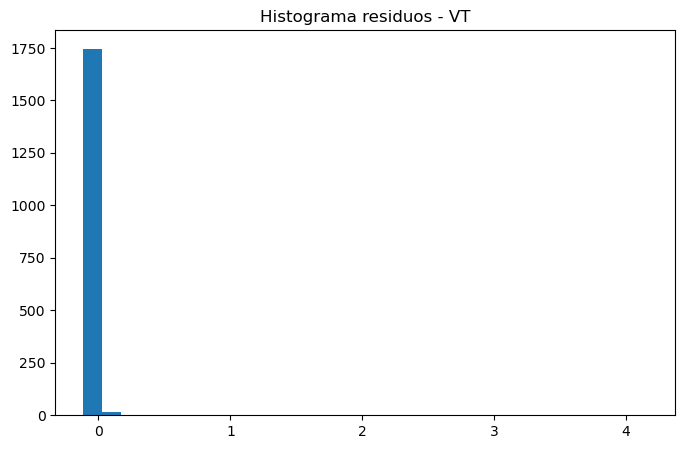

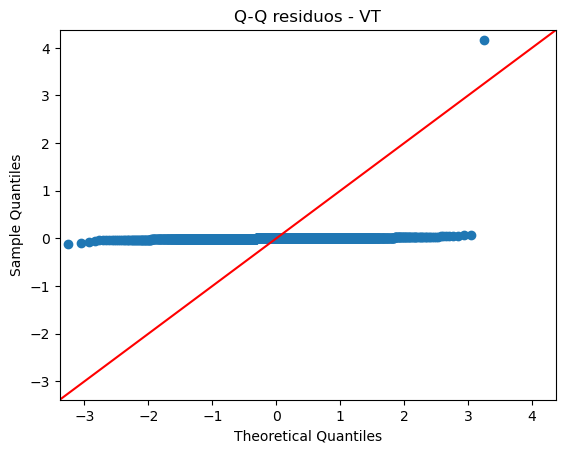


SARIMA - VYM


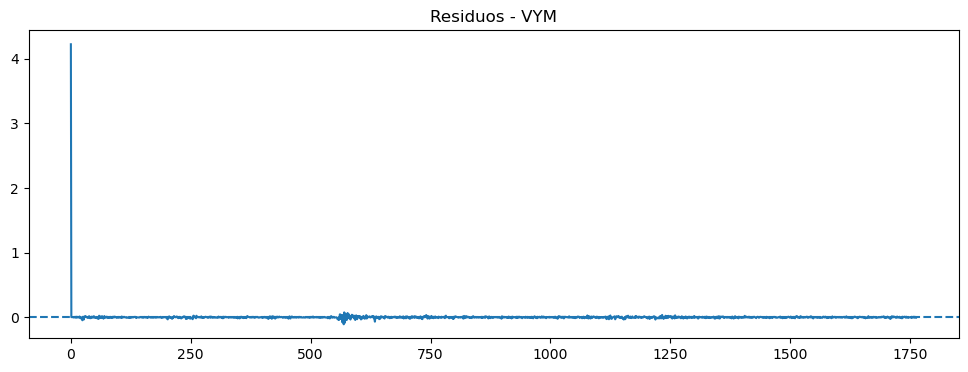

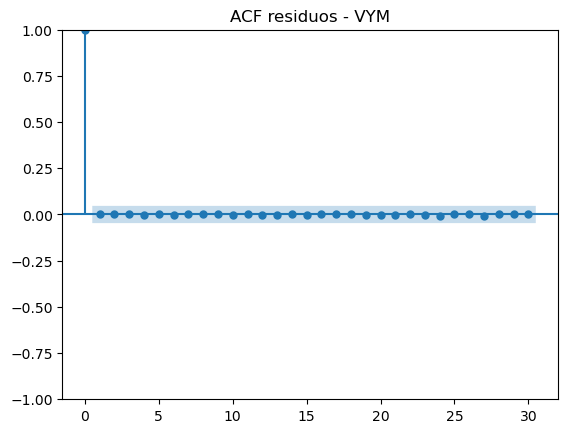

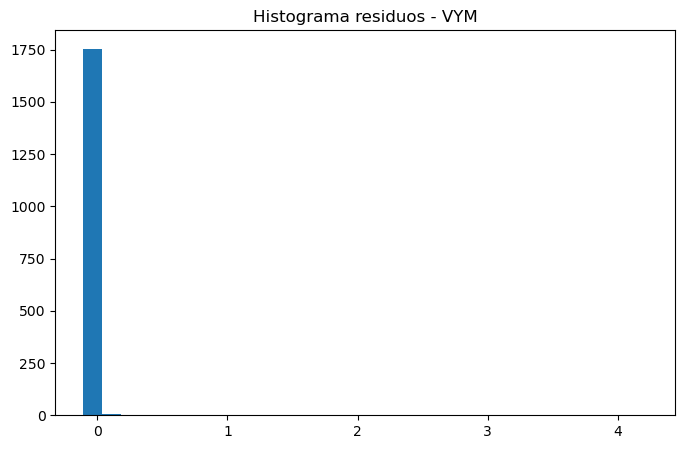

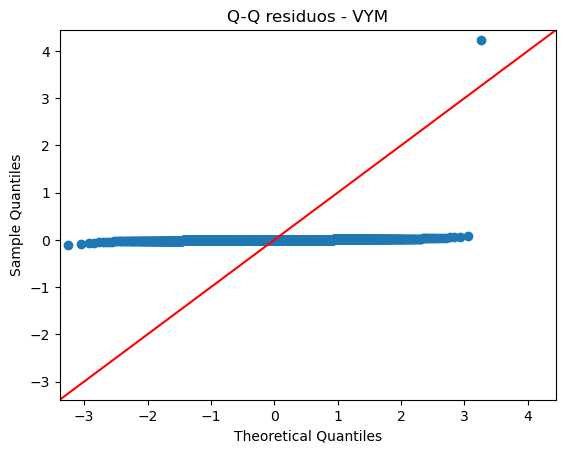


SARIMA - WMB


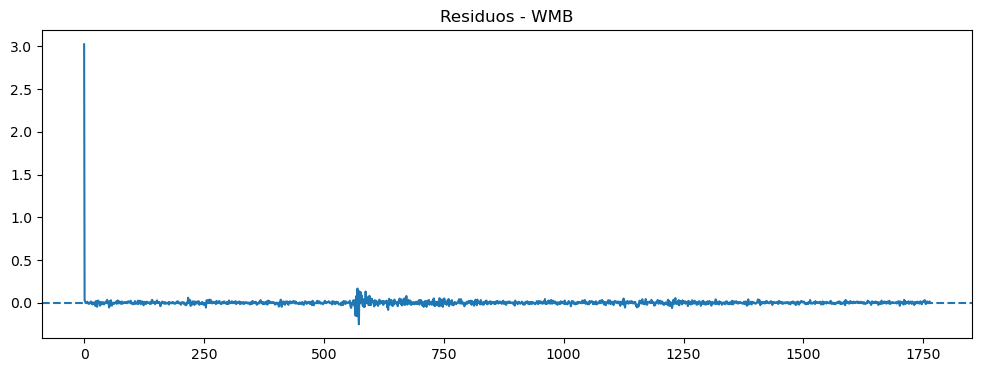

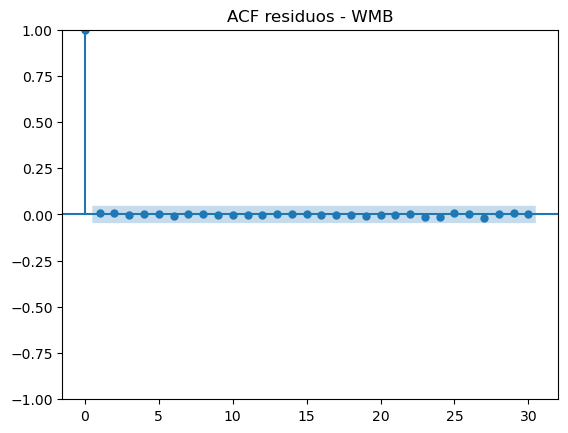

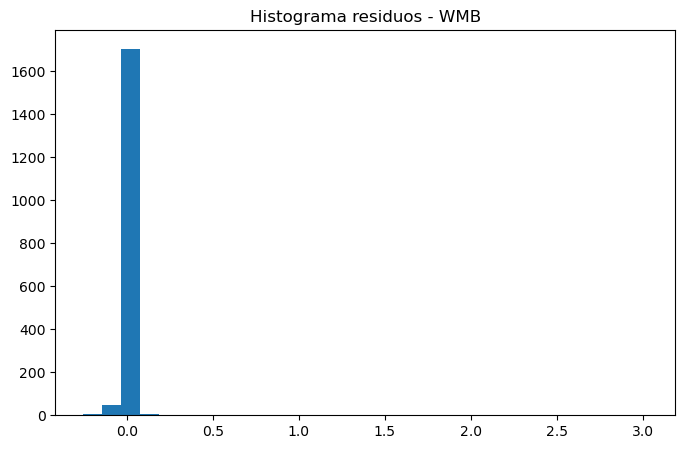

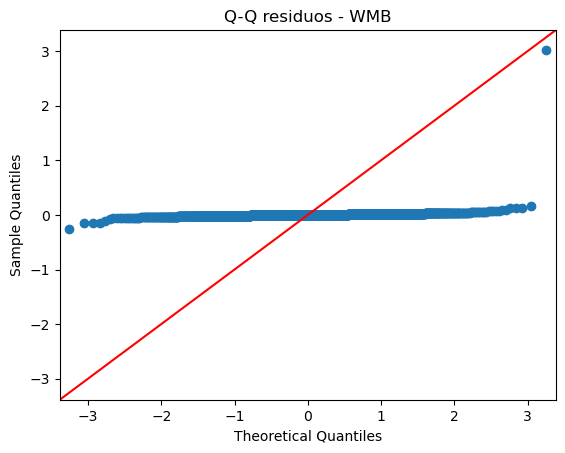


SARIMA - X


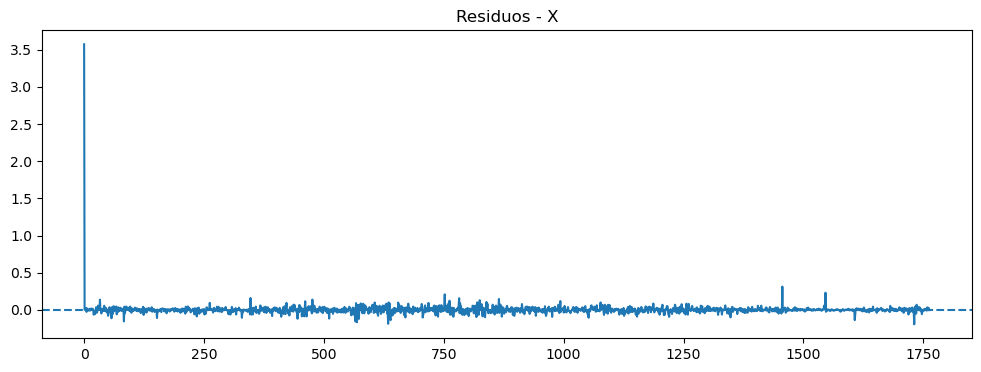

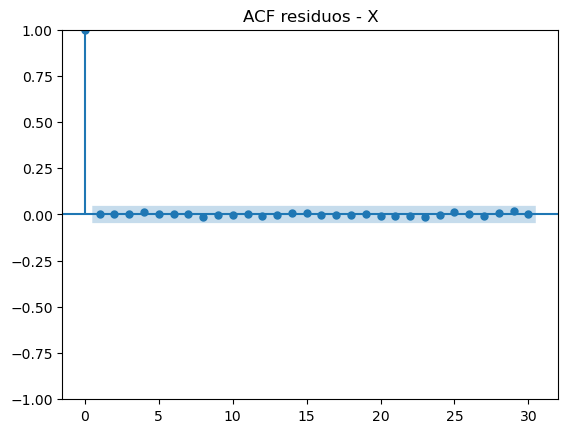

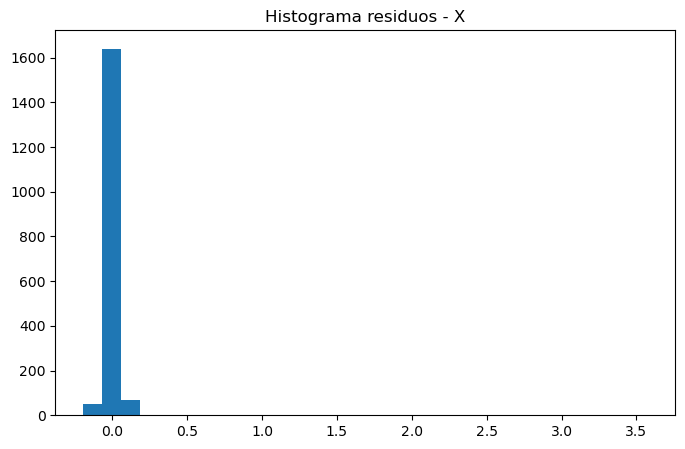

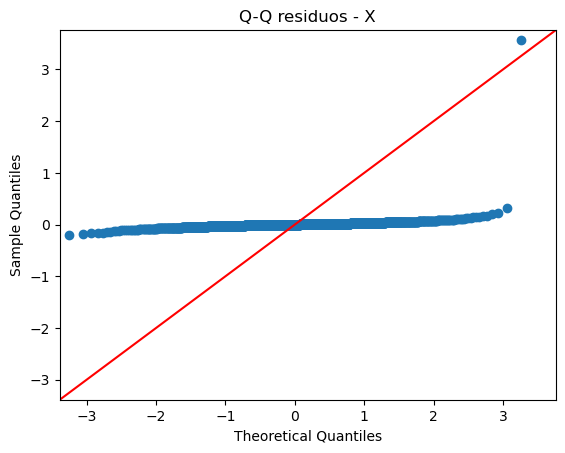


SARIMA - XOM


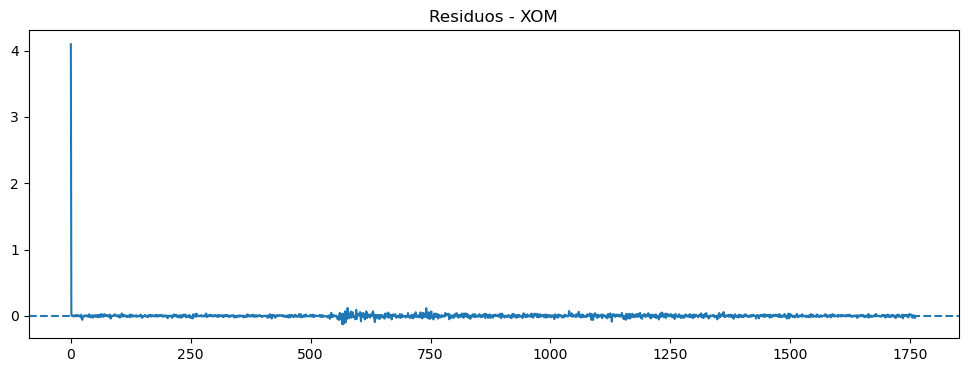

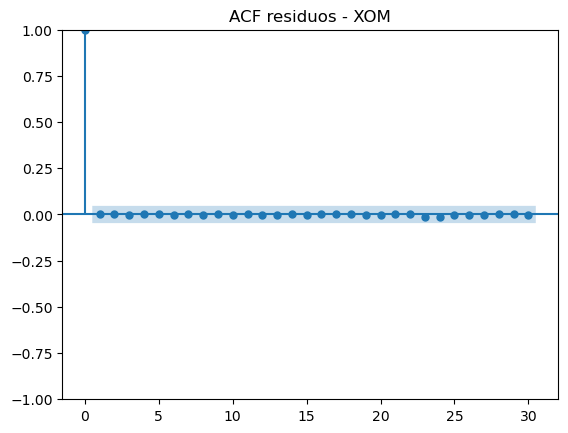

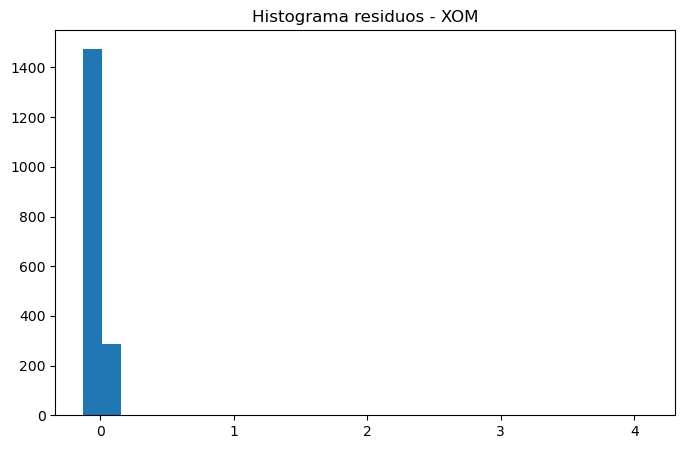

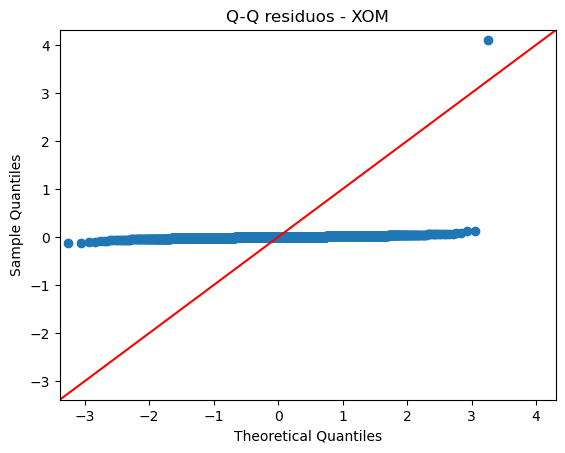

In [31]:
for variable, modelo in modelos_sarima.items():

    print("\n" + "=" * 70)
    print(f"SARIMA - {variable}")
    print("=" * 70)

    diagnosticos_graficos(modelo,variable,lags=30)